## 1. Import Packages

In [1]:
import json
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

try:
    from PIL import Image
except ImportError:
    class Image:
        @staticmethod
        def open(path):
            return Path(path)


## 2. Import All Backend and Helper Functions

In [2]:

AUXILIARY_CANDIDATES = [
    Path.cwd() / 'simulation_backend.ipynb',
    Path('/Users/tristan/Downloads/simulation_backend.ipynb'),
    Path('/Users/tristan/Documents/diagnostics/simulation_backend.ipynb'),
]
AUXILIARY_NOTEBOOK = next((path for path in AUXILIARY_CANDIDATES if path.exists()), None)
if AUXILIARY_NOTEBOOK is None:
    searched = '\n'.join(str(path) for path in AUXILIARY_CANDIDATES)
    raise FileNotFoundError(f'Could not find simulation_backend.ipynb. Searched:\n{searched}')

with AUXILIARY_NOTEBOOK.open() as handle:
    auxiliary = json.load(handle)

for cell in auxiliary['cells']:
    if cell['cell_type'] != 'code':
        continue
    exec(''.join(cell['source']), globals())


## 3. Experimental Configuration

Each experiment keeps a compact config and now includes explicit 1D/2D display ranges. All exported plots are collected into a single clean output folder as both PNG and SVG.


In [3]:

EXPERIMENT_SPECS = [
    {
        'title': 'Experiment 1: a=0.05, r=0.40, deltar=0, deltas=0, vary deltar',
        'config': {
            'model_name': 'simulation_experiment_1_deltar',
            'primary_continuation_parameter': 'mu',
            'secondary_continuation_parameter': 'deltar',
            'secondary_min': 0.0,
            'secondary_max': 0.4,
            'two_d_plot_ymin': 0.0,
            'two_d_plot_ymax': 0.1,
            'one_d_plot_max': 0.1,
            'bistability_plot_max': 0.1,
        },
        'parameter_updates': {
            'a': '0.05',
            'r': '0.40',
            'deltar': '0.0',
            'deltas': '0.0',
        },
    },
    {
        'title': 'Experiment 2: a=0.05, r=0.40, deltar=0, deltas=0, vary deltas',
        'config': {
            'model_name': 'simulation_experiment_2_deltas',
            'primary_continuation_parameter': 'mu',
            'secondary_continuation_parameter': 'deltas',
            'secondary_min': 0.0,
            'secondary_max': 0.4,
            'two_d_plot_ymin': 0.0,
            'two_d_plot_ymax': 0.1,
            'one_d_plot_max': 0.1,
            'bistability_plot_max': 0.1,
        },
        'parameter_updates': {
            'a': '0.05',
            'r': '0.40',
            'deltar': '0.0',
            'deltas': '0.0',
        },
    },
    {
        'title': 'Experiment 3: a=0.05, r=0.40, deltar=0.2, deltas=0.02, vary beta',
        'config': {
            'model_name': 'simulation_experiment_3_beta',
            'primary_continuation_parameter': 'mu',
            'secondary_continuation_parameter': 'beta',
            'secondary_min': 0.0,
            'secondary_max': 4.0,
            'two_d_plot_ymin': 0.0,
            'two_d_plot_ymax': 0.1,
            'one_d_plot_max': 0.1,
            'bistability_plot_max': 0.1,
        },
        'parameter_updates': {
            'a': '0.05',
            'r': '0.40',
            'deltar': '0.2',
            'deltas': '0.02',
        },
    },
]


## 4. Model


\begin{aligned}
\textbf{Patch contrasts:} \qquad 
&r_L = r + \Delta r,\qquad r_P = r - \Delta r,\\[4pt]
&a_P = a + \Delta s,\qquad a_L = a - \Delta s.
\end{aligned}


\begin{aligned}
\textbf{Fitness functions:} \qquad 
&w_{PL}=0,\\[4pt]
&w_{PP}=0,\\[4pt]
&w_{FL}=(r_L-bF_L)-\frac{a_LP_LF_L}{1+sF_L^2}+eqJ_L,\\[6pt]
&w_{FP}=(r_P-bF_P)-\frac{a_PP_PF_P}{1+sF_P^2}+eqJ_P,\\[6pt]
&w_{JL}=\frac{g}{1+J_L^2}-qF_L-cP_L,\\[6pt]
&w_{JP}=\frac{g}{1+J_P^2}-qF_P-cP_P.
\end{aligned}



\begin{aligned}
\textbf{Movement function:} \qquad 
&E = \mathrm{toggle}\,d\left(\frac{1}{1+\exp\left[-\beta\alpha\left(w_{\mathrm{out}}-w_{\mathrm{in}}\right)\right]}\right).
\end{aligned}



\begin{aligned}
\frac{dP_L}{dt}&=\frac{gJ_L}{1+J_L^2}-(m_P+\mu)P_L,\\
\frac{dP_P}{dt}&=\frac{gJ_P}{1+J_P^2}-(m_P+\mu)P_P,\\
\frac{dF_L}{dt}&=(r_LF_L-bF_L^2)-\frac{a_LP_LF_L^2}{1+sF_L^2}+eqF_LJ_L,\\
\frac{dF_P}{dt}&=(r_PF_P-bF_P^2)-\frac{a_PP_PF_P^2}{1+sF_P^2}+eqF_PJ_P,\\
\frac{dJ_L}{dt}&=\mathrm{fec}_L P_L-\frac{gJ_L}{1+J_L^2}-m_JJ_L-qF_LJ_L-cP_LJ_L,\\
\frac{dJ_P}{dt}&=\mathrm{fec}_P P_P-\frac{gJ_P}{1+J_P^2}-m_JJ_P-qF_PJ_P-cP_PJ_P.
\end{aligned}

In [4]:
RQ1_ODE_TEXT = dedent(r'''
# --------------------------- Helper Functions --------------------------------

# Functional Forms
maturation(g,j) = (g*j)/(1+j*j)
type3(a,p,f,s) = (a*p*f*f)/(1+s*f*f)
logistic(r,b,f) = r*f - b*f*f
sig(a) = 1/(1+exp(-a))
type1(a,x,y) = a*x*y
type3ff(a,s,f) = (a*f*f)/(1+s*f*f)

# Delta
rL = r + deltar
rP = r - deltar
aP = a + deltas
aL = a - deltas

# Fitness
fitPL(f,p,j) = 0
fitPP(f,p,j) = 0
fitFL(f,p,j) = (rL - bL*f) - (aL*p*f)/(1 + sL*f*f) + eL*qL*j
fitFP(f,p,j) = (rP - bP*f) - (aP*p*f)/(1 + sP*f*f) + eP*qP*j 
fitJL(p,f,j) = (gL/(1 + j*j)) - qL*f - cL*p 
fitJP(p,f,j) = (gP/(1 + j*j)) - qP*f - cP*p 

# Movement
emig(d,toggle,alpha,win,wout) = toggle*d*(sig(beta*alpha*(wout - win)))

# -------------------------- Governing Equations ------------------------------

# Adult Predator - littoral
PL' = maturation(gL,JL) - (mP+mu)*PL \
      - emig(dP,toggle,alphaP, fitPL(FL,PL,JL), fitPP(FP,PP,JP))*PL \
      + emig(dP,toggle,alphaP, fitPP(FP,PP,JP), fitPL(FL,PL,JL))*PP

# Forager - littoral
FL' = logistic(rL,bL,FL) - type3(aL,PL,FL,sL) + type1(eL*qL,FL,JL) \
      - emig(dF,toggle,alphaF, fitFL(FL,PL,JL), fitFP(FP,PP,JP))*FL \
      + emig(dF,toggle,alphaF, fitFP(FP,PP,JP), fitFL(FL,PL,JL))*FP

# Juvenile - littoral
JL' = fecL*PL - maturation(gL,JL) - mJ*JL \
      - type1(qL,FL,JL) - type1(cL,PL,JL) \
      - emig(dJ,toggle,alphaJ, fitJL(PL,FL,JL), fitJP(PP,FP,JP))*JL \
      + emig(dJ,toggle,alphaJ, fitJP(PP,FP,JP), fitJL(PL,FL,JL))*JP

# Adult Predator - pelagic
PP' = maturation(gP,JP) - (mP+mu)*PP \
      - emig(dP,toggle,alphaP, fitPP(FP,PP,JP), fitPL(FL,PL,JL))*PP \
      + emig(dP,toggle,alphaP, fitPL(FL,PL,JL), fitPP(FP,PP,JP))*PL

# Forager - pelagic
FP' = logistic(rP,bP,FP) - type3(aP,PP,FP,sP) + type1(eP*qP,FP,JP) \
      - emig(dF,toggle,alphaF, fitFP(FP,PP,JP), fitFL(FL,PL,JL))*FP \
      + emig(dF,toggle,alphaF, fitFL(FL,PL,JL), fitFP(FP,PP,JP))*FL

# Juvenile - pelagic
JP' = fecP*PP - maturation(gP,JP) - mJ*JP \
      - type1(qP,FP,JP) - type1(cP,PP,JP) \
      - emig(dJ,toggle,alphaJ, fitJP(PP,FP,JP), fitJL(PL,FL,JL))*JP \
      + emig(dJ,toggle,alphaJ, fitJL(PL,FL,JL), fitJP(PP,FP,JP))*JL

# -------------------------- Parameters ---------------------------------------


par r=0.400
par a=0.05

par mP=0.1, mJ=0.1

par bL=0.060, sL=0.005
par bP=0.060, sP=0.005

par eL=0.100, eP=0.100
par fecL=1, fecP=1
par gL=0.2, gP=0.2
par qL=0.2, qP=0.2, cL=0.02, cP=0.02

par dP=0.1, dF=0.1, dJ=0.1
par alphaP=0.25, alphaF=0.25, alphaJ=0.25
par omegap=0.01, omegaf=0.01, omegaj=0.01

par mu=0
par deltar=0.0
par deltas=0.00
par beta=0


par toggle=1

# -------------------------- Initial Conditions -------------------------------

init PL=5, FL=5, JL=5
init PP=5, FP=5, JP=5

@ total=1000, dt=0.1, bounds=1000

# --------------------------- Plotting Variables ------------------------------

@ XP=t, YP=PL, XLO=0, XHIGH=1000, YLOW=-0.1, YHIGH=10

# ------------------------------- Auto Options --------------------------------

@ DS=0.0005, DSMIN=0.0001, DSMAX=0.05, NMAX=500
@ PARMIN=-0.25, PARMAX=0.5, NORMMAX=20
@ AUTOXMIN=-0.2, AUTOXMAX=0.5, AUTOYMIN=-0.1, AUTOYMAX=5

# ----------------------- 2 Parameter Bifurcation Plot ------------------------

@ AUTOYMIN=0, AUTOYMAX=0.4
''').strip() + "\n"


## 5. Prepare Helpers and Output Folder


In [5]:

import re

PLOT_OUTPUT_DIR = Path.cwd() / 'simulation_plot_outputs'
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def apply_parameter_updates(ode_text, updates):
    updated_lines = []
    for line in ode_text.splitlines():
        if line.strip().startswith('par '):
            updated_line = line
            for name, value in updates.items():
                pattern = rf'(?<![A-Za-z0-9_]){re.escape(name)}\s*=\s*([^,]+)'
                updated_line = re.sub(pattern, f'{name}={value}', updated_line)
            updated_lines.append(updated_line)
        else:
            updated_lines.append(line)
    return '\n'.join(updated_lines) + '\n'


def export_plot_variants(save_callable, png_path, svg_path):
    save_callable(png_path)
    save_callable(svg_path)


def print_diagram_endpoints(diagram, x_name, y_name, label):
    branches = list(getattr(diagram, 'branches', diagram))
    print(f'{label} endpoints:')
    for idx, branch in enumerate(branches, start=1):
        coordnames = list(getattr(branch, 'coordnames', []))
        if x_name not in coordnames or y_name not in coordnames:
            print(f'  Branch {idx}: missing {x_name}/{y_name} coordinates')
            continue
        x = branch.coordarray[coordnames.index(x_name)]
        y = branch.coordarray[coordnames.index(y_name)]
        if len(x) == 0 or len(y) == 0:
            print(f'  Branch {idx}: empty branch')
            continue
        print(
            f'  Branch {idx}: start=({float(x[0]):.6f}, {float(y[0]):.6f}) '
            f'end=({float(x[-1]):.6f}, {float(y[-1]):.6f})'
        )


def run_experiment(spec):
    ode_text = apply_parameter_updates(RQ1_ODE_TEXT, spec['parameter_updates'])
    experiment = prepare_experiment(spec['config'], ode_text)
    run_one_d_continuation(experiment)

    one_d_png = PLOT_OUTPUT_DIR / f"{experiment['model_name']}_1d.png"
    one_d_svg = PLOT_OUTPUT_DIR / f"{experiment['model_name']}_1d.svg"
    export_plot_variants(
        lambda output_path: save_one_d_plot(experiment, filename=output_path),
        one_d_png,
        one_d_svg,
    )

    run_two_d_continuation(experiment)
    two_d_png = PLOT_OUTPUT_DIR / f"{experiment['model_name']}_2d.png"
    two_d_svg = PLOT_OUTPUT_DIR / f"{experiment['model_name']}_2d.svg"
    plotter = HeadlessAutoPlotter('codim2')
    configure_auto_2d_plot(plotter, experiment, grid=False)
    export_plot_variants(plotter.savefig, two_d_png, two_d_svg)

    print_diagram_endpoints(
        experiment['eq_diagram'],
        experiment['config']['primary_continuation_parameter'],
        experiment['config']['plot_state'],
        f"{spec['title']} 1D",
    )
    print_diagram_endpoints(
        experiment['codim2'],
        experiment['config']['secondary_continuation_parameter'],
        experiment['config']['primary_continuation_parameter'],
        f"{spec['title']} 2D",
    )

    return {
        'title': spec['title'],
        'experiment': experiment,
        'ode_text': ode_text,
        'one_d_png': one_d_png,
        'one_d_svg': one_d_svg,
        'two_d_png': two_d_png,
        'two_d_svg': two_d_svg,
    }


## 6. Run All Three Experiments and Display Exported Plots


gfortran -g -fopenmp -O -c simulation_experiment_1_deltar.f90 -o simulation_experiment_1_deltar.o
gfortran -g -fopenmp -O simulation_experiment_1_deltar.o -o simulation_experiment_1_deltar.exe /auto/lib/*.o
Starting simulation_experiment_1_deltar ...

  BR    PT  TY  LAB       mu         L2-NORM          PL            FL            JL            PP            FP            JP      
   1     1  EP    1   0.00000E+00   9.42809E+00   0.00000E+00   6.66667E+00   0.00000E+00   0.00000E+00   6.66667E+00   0.00000E+00
   1     7  BP    2   2.24490E-02   9.42809E+00  -2.68776E-33   6.66667E+00  -1.64557E-33  -2.68776E-33   6.66667E+00  -1.64557E-33
   1    18  UZ    3   5.00000E-01   9.42809E+00   1.74227-109   6.66667E+00   4.83387-110   1.77138-109   6.66667E+00   4.93782-110

  BR    PT  TY  LAB       mu         L2-NORM          PL            FL            JL            PP            FP            JP      
   2    53  LP    4   3.72113E-02   7.44459E+00   3.97058E-01   5.24075E+00   2.96323

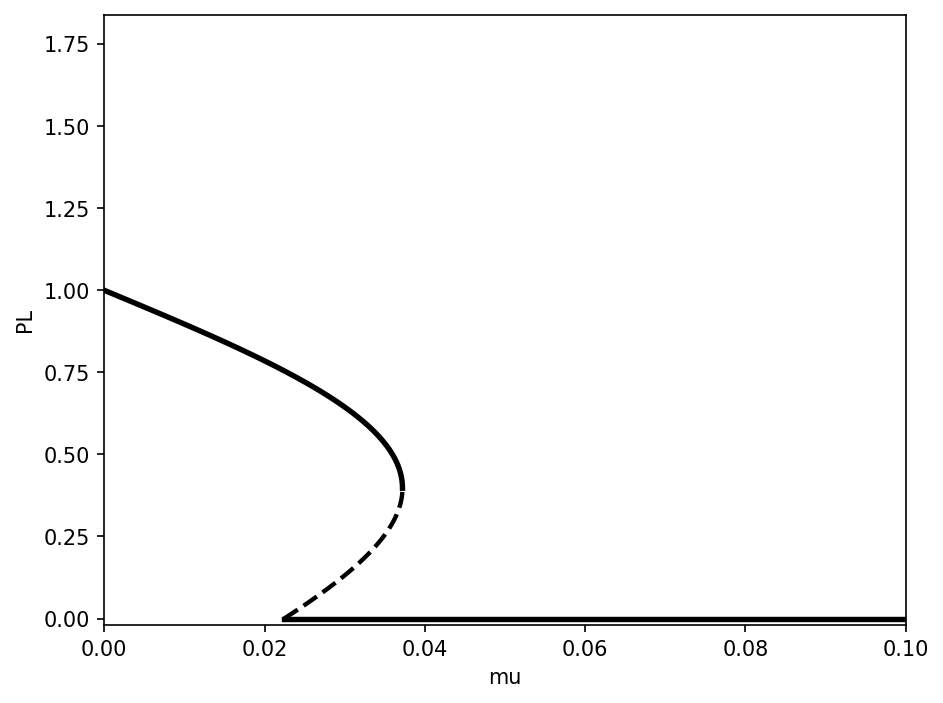

2D PNG: /auto/Simulations/simulation_plot_outputs/simulation_experiment_1_deltar_2d.png
2D SVG: /auto/Simulations/simulation_plot_outputs/simulation_experiment_1_deltar_2d.svg


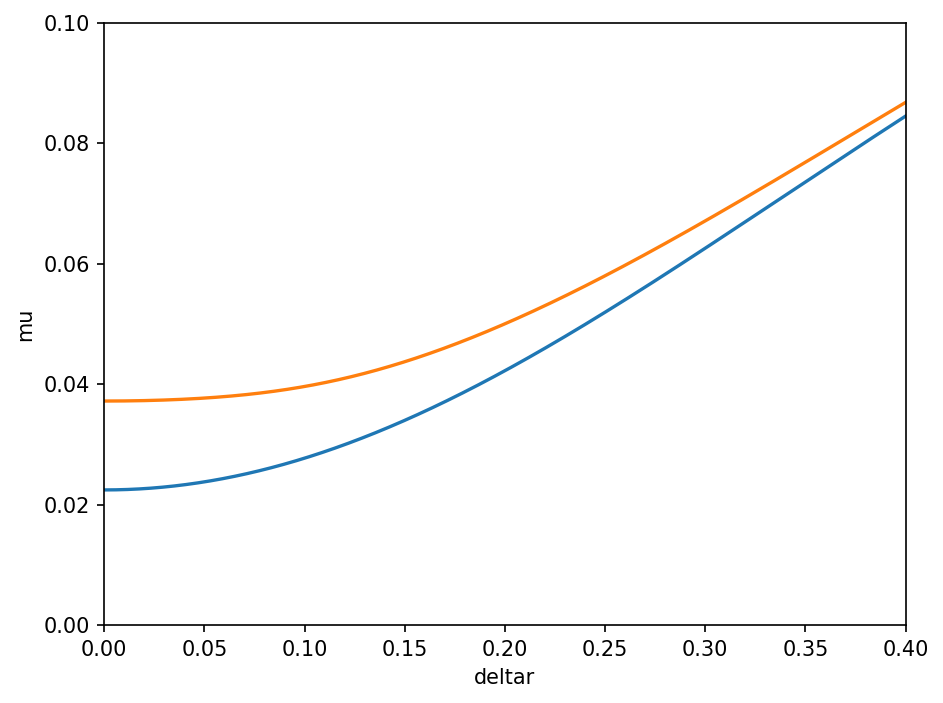

gfortran -g -fopenmp -O -c simulation_experiment_2_deltas.f90 -o simulation_experiment_2_deltas.o
gfortran -g -fopenmp -O simulation_experiment_2_deltas.o -o simulation_experiment_2_deltas.exe /auto/lib/*.o
Starting simulation_experiment_2_deltas ...

  BR    PT  TY  LAB       mu         L2-NORM          PL            FL            JL            PP            FP            JP      
   1     1  EP    1   0.00000E+00   9.42809E+00   0.00000E+00   6.66667E+00   0.00000E+00   0.00000E+00   6.66667E+00   0.00000E+00
   1     7  BP    2   2.24490E-02   9.42809E+00  -2.68776E-33   6.66667E+00  -1.64557E-33  -2.68776E-33   6.66667E+00  -1.64557E-33
   1    18  UZ    3   5.00000E-01   9.42809E+00   1.74227-109   6.66667E+00   4.83387-110   1.77138-109   6.66667E+00   4.93782-110

  BR    PT  TY  LAB       mu         L2-NORM          PL            FL            JL            PP            FP            JP      
   2    53  LP    4   3.72113E-02   7.44459E+00   3.97058E-01   5.24075E+00   2.96323

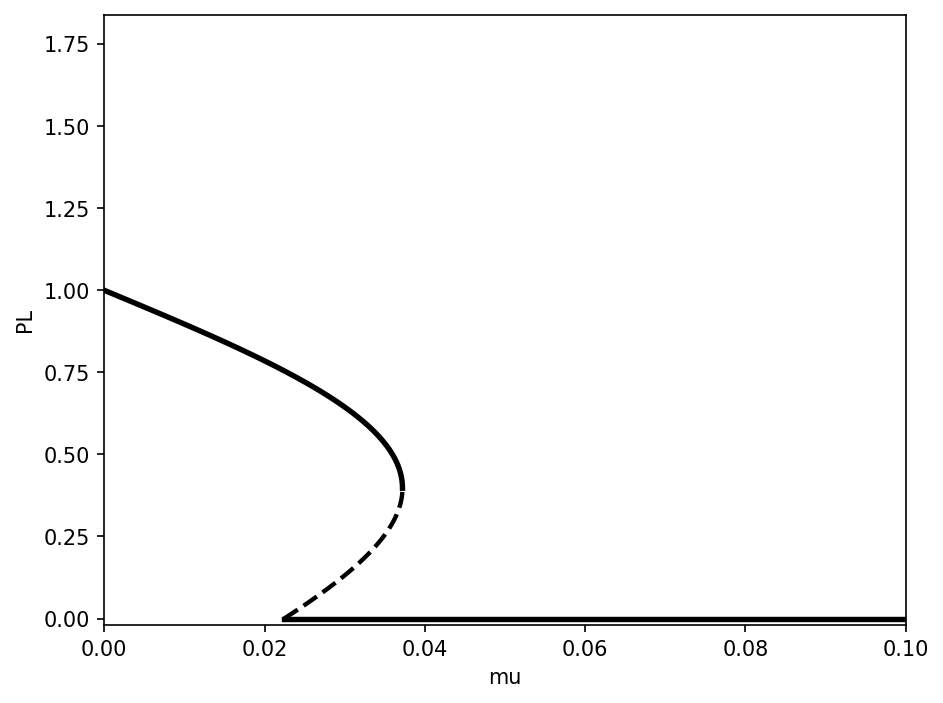

2D PNG: /auto/Simulations/simulation_plot_outputs/simulation_experiment_2_deltas_2d.png
2D SVG: /auto/Simulations/simulation_plot_outputs/simulation_experiment_2_deltas_2d.svg


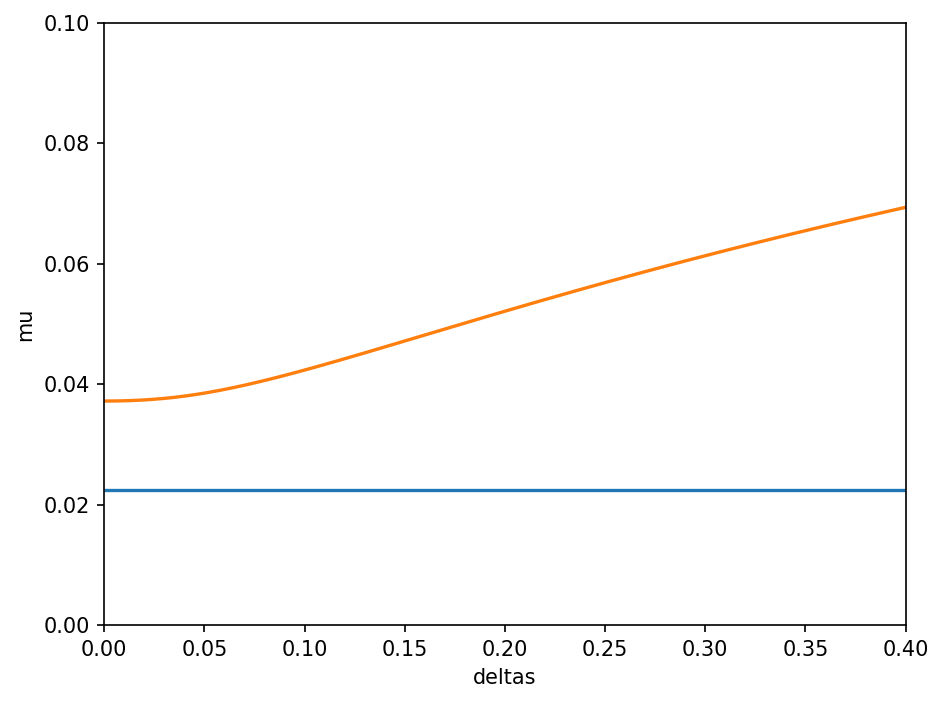

gfortran -g -fopenmp -O -c simulation_experiment_3_beta.f90 -o simulation_experiment_3_beta.o
gfortran -g -fopenmp -O simulation_experiment_3_beta.o -o simulation_experiment_3_beta.exe /auto/lib/*.o
Starting simulation_experiment_3_beta ...

  BR    PT  TY  LAB       mu         L2-NORM          PL            FL            JL            PP            FP            JP      
   1     1  EP    1   0.00000E+00   1.04834E+01   0.00000E+00   9.54513E+00   0.00000E+00   0.00000E+00   4.33493E+00   0.00000E+00
   1     8  BP    2   4.22531E-02   1.04834E+01  -5.50795E-24   9.54513E+00  -2.63414E-24  -1.06419E-23   4.33493E+00  -8.85267E-24
   1    18  UZ    3   5.00000E-01   1.04834E+01  -1.61671E-32   9.54513E+00  -7.16897E-33  -6.94295E-34   4.33493E+00  -5.54649E-34

  BR    PT  TY  LAB       mu         L2-NORM          PL            FL            JL            PP            FP            JP      
   2    29  LP    4   5.27333E-02   9.80902E+00   1.29012E-01   9.10517E+00   6.51235E-02   2.6

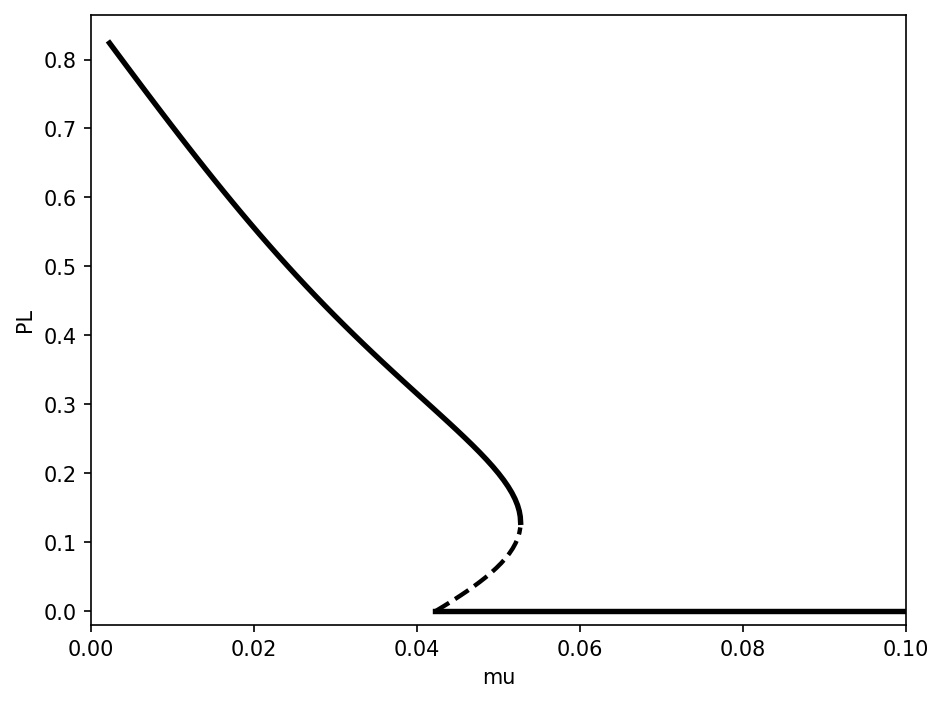

2D PNG: /auto/Simulations/simulation_plot_outputs/simulation_experiment_3_beta_2d.png
2D SVG: /auto/Simulations/simulation_plot_outputs/simulation_experiment_3_beta_2d.svg


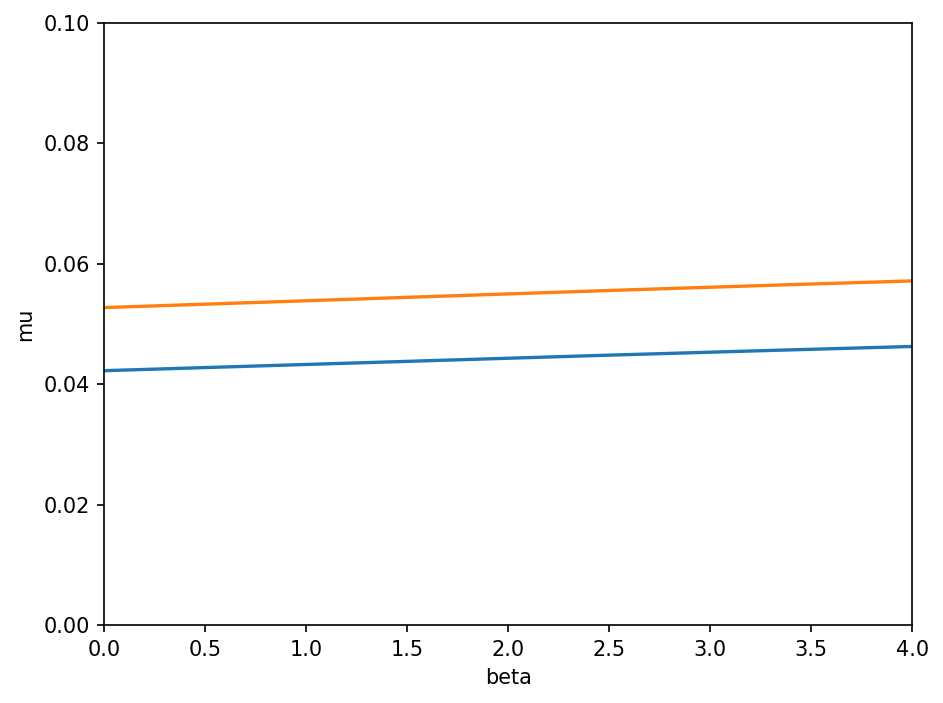

In [6]:

RESULTS = []
for spec in EXPERIMENT_SPECS:
    result = run_experiment(spec)
    RESULTS.append(result)

    print(result['title'])
    print('1D PNG:', result['one_d_png'])
    print('1D SVG:', result['one_d_svg'])
    display(Image.open(result['one_d_png']))
    print('2D PNG:', result['two_d_png'])
    print('2D SVG:', result['two_d_svg'])
    display(Image.open(result['two_d_png']))


## 7. Generated Experiment Objects and Output Folder


In [7]:

{
    'output_folder': PLOT_OUTPUT_DIR,
    'experiments': [(result['title'], result['experiment']['workdir']) for result in RESULTS],
}


{'output_folder': PosixPath('/auto/Simulations/simulation_plot_outputs'),
 'experiments': [('Experiment 1: a=0.05, r=0.40, deltar=0, deltas=0, vary deltar',
   PosixPath('/auto/Simulations/simulation_experiment_1_deltar_auto')),
  ('Experiment 2: a=0.05, r=0.40, deltar=0, deltas=0, vary deltas',
   PosixPath('/auto/Simulations/simulation_experiment_1_deltar_auto/simulation_experiment_2_deltas_auto')),
  ('Experiment 3: a=0.05, r=0.40, deltar=0.2, deltas=0.02, vary beta',
   PosixPath('/auto/Simulations/simulation_experiment_1_deltar_auto/simulation_experiment_2_deltas_auto/simulation_experiment_3_beta_auto'))]}